# Support Vector Machines

This note contains all the code examples of my SVM learning process.

Import packages:

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets as sk_datasets
import sklearn.svm as svm_models
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

## Linear SVM

Let's try to train simple linear SVM on Iris dataset, shown in `3-Training-Linear-Models.ipynb`

In [36]:
iris = sk_datasets.load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [37]:
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [38]:
X = iris.data[["sepal length (cm)", "sepal width (cm)"]].values
y = iris.target == 2

In [39]:
lin_svm = svm_models.LinearSVC()
lin_svm.fit(X, y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [40]:
new_iris_data = [[6.5, 1.7], [5.0, 1.5]]
lin_svm.predict(new_iris_data)

array([ True, False])

In [41]:
lin_svm.decision_function(new_iris_data)

array([ 0.55808211, -0.36219434])

## Non-Linear SVM Classification

If our data cannot be linearly separable, we can artificially supplement our dataset with polynomial features _(discussed in 3-Training-Linear-Models.ipynb)_

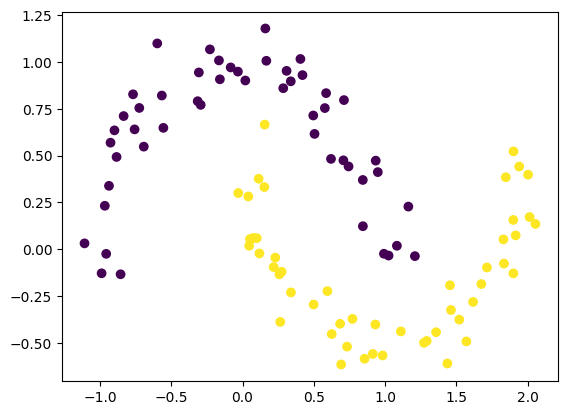

In [42]:
X, y = sk_datasets.make_moons(n_samples=100, noise=0.1)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [43]:
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    svm_models.LinearSVC(C=1.0),
)
polynomial_svm_clf.fit(X, y)

,steps,"[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


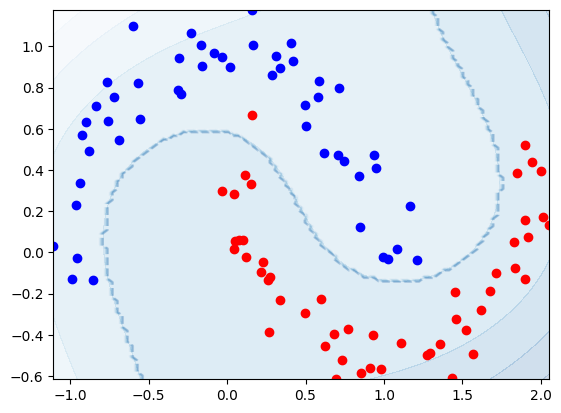

In [44]:
def plot_bin_clf_dataset(X, y):
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

def plot_svm(svm, axes):
    X_0, X_1 = np.linspace(axes[0], axes[1], 100), np.linspace(axes[2], axes[3], 100)

    # Contains every possible point of the generated X_0 and X_1 coordinates
    X0s, X1s = np.meshgrid(X_0, X_1)
    X = np.c_[X0s.ravel(), X1s.ravel()]

    # Reshaping to make the same shape as our coordinate grid
    y_pred = svm.predict(X).reshape(X0s.shape)
    y_decision = svm.decision_function(X).reshape(X0s.shape)

    plt.contourf(X0s, X1s, y_decision, cmap="Blues", alpha=0.2) # Decision function values map
    plt.contour(X0s, X1s, y_pred, cmap="Blues", alpha=0.2, linestyles=["--"]) # Decision boundary


plot_svm(polynomial_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_bin_clf_dataset(X, y)

On the plot, we can see that the model correctly got the data nature. Plot like this can help us to see how regularization $C$, number of freedom degrees are affecting the model.

> The plot is basically a projection of the 3D figure, where $x, y$ are our features, and $z$ is a result of a decision_function.

Here is example of how overfitting model would look like on the same dataset:

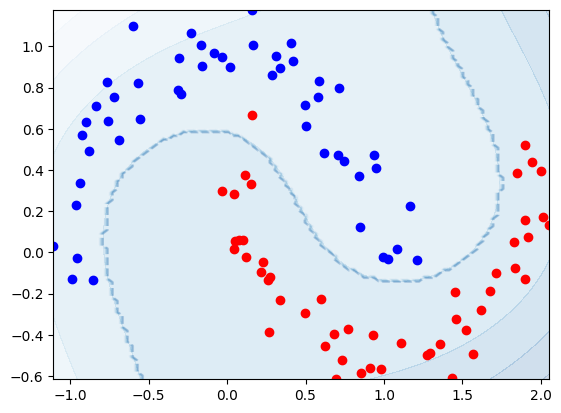

In [45]:
polynomial_svm_clf_overfit = make_pipeline(
    PolynomialFeatures(degree=30),
    StandardScaler(),
    svm_models.LinearSVC(C=10.0, max_iter=10000),
)
polynomial_svm_clf_overfit.fit(X, y)

plot_svm(polynomial_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_bin_clf_dataset(X, y)

## Polynomial Kernel

Polynomial Kernel allows you to apply kernel trick, to get same model based on polynomial features without having to add them!

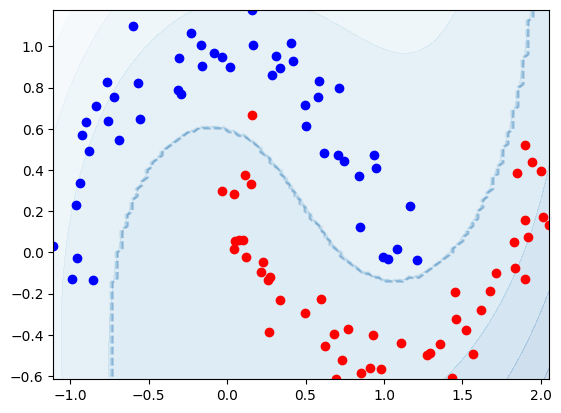

In [46]:
poly_kernel_svm_clf = svm_models.SVC(kernel="poly", degree=3, C=1.0, coef0=1)
poly_kernel_svm_clf.fit(X, y)

plot_svm(poly_kernel_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_bin_clf_dataset(X, y)

See? We got same model as in first plot! Without troubles with explosion of number of features

## SVM Regression

SVMs are also capable of generalizing regression tasks. Let's create linear dataset and see how it works:

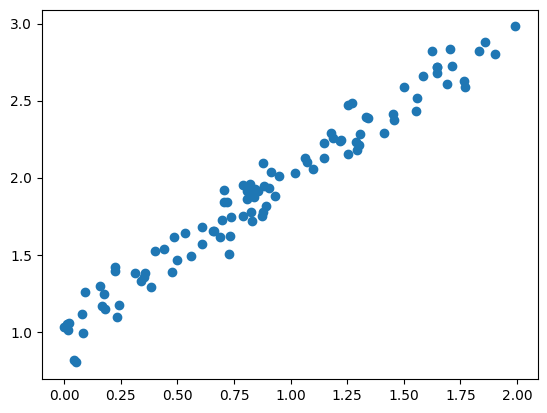

In [51]:
X = 2 * np.random.rand(100, 1)
y = X + 1 + np.random.randn(100, 1) * 0.1

def plot_lin_reg_dataset(X: np.array, y: np.array, scatter: bool = True) -> None:
    if scatter:
        plt.scatter(X, y)
    else:
        plt.plot(X, y, color="red")

plot_lin_reg_dataset(X, y)

In [52]:
svm_reg = make_pipeline(
    StandardScaler(),
    svm_models.LinearSVR(epsilon=0.1, C=10)
)
svm_reg.fit(X, y.ravel())

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,steps,"[('standardscaler', ...), ('linearsvr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,epsilon,0.1
,tol,0.0001
,C,10
,loss,'epsilon_insensitive'


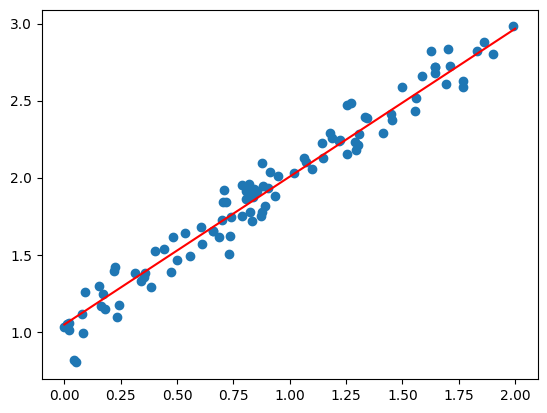

In [53]:
X_new = 2 * np.linspace(0, 1, 100)[:, np.newaxis]
predictions = svm_reg.predict(X_new)
plot_lin_reg_dataset(X, y)
plot_lin_reg_dataset(X_new, predictions, scatter=False)

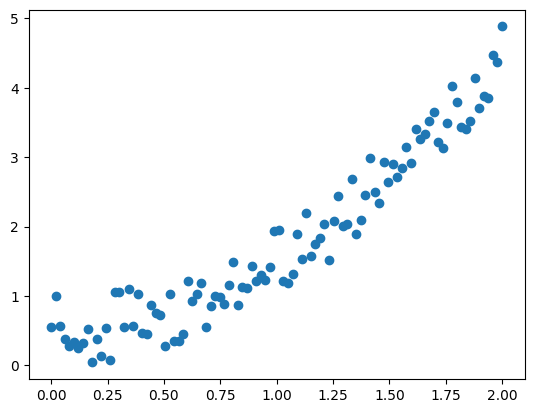

In [56]:
X_poly = 2 * np.linspace(0, 1, 100)[:, np.newaxis]
y_poly = X_poly ** 2 + np.random.rand(100, 1)

plot_lin_reg_dataset(X_poly, y_poly)

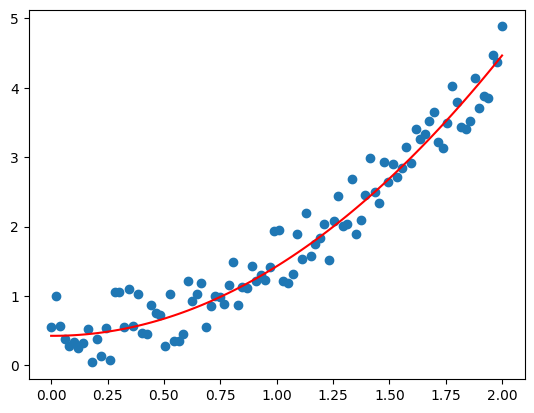

In [74]:
svm_poly_reg = make_pipeline(
    StandardScaler(),
    svm_models.SVR(
        kernel="poly",
        degree=2,
        C=100,
        epsilon=0.05,
        coef0=1
    )
)
svm_poly_reg.fit(X_poly, y_poly.ravel())
X_new_poly = np.linspace(0, 2, 100)[:, np.newaxis]
poly_predictions = svm_poly_reg.predict(X_new_poly)
plot_lin_reg_dataset(X_poly, y_poly)
plot_lin_reg_dataset(X_new_poly, poly_predictions, scatter=False)